# **Sales Data Analysis Project**

##*This project focuses on cleaning, exploring, and analyzing sales data from a global company operating both online and offline.*

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")

%cd /content/drive/MyDrive/Python_DA

# import CSV file
countries = pd.read_csv("countries.csv")
events = pd.read_csv("events.csv")
products = pd.read_csv("products.csv")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Python_DA


## Data Structure

 Here we inspect the first rows and data types of each dataset.

In [ ]:
countries.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [ ]:
events.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
products.head()

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


## Key Relationships Between Tables

- Product ID → links events and products  
- Country Code → links events and countries  

## Data Structure

We inspect data types and check for missing values.

In [ ]:
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


In [ ]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


In [ ]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


##Summary
The events dataset contains the main data and has some missing values and incorrect data types (dates as objects). The countries dataset has minor missing values, while the products dataset is clean. Data preprocessing is required before analysis.

## Data Cleaning

In this section, we check for missing values, evaluate their proportion, and analyze possible reasons for their occurrence.

### Missing Values Check

In [ ]:
countries.isnull().sum()

,0
name,0
alpha-2,1
alpha-3,0
region,1
sub-region,1


In [ ]:
events.isnull().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,82
Product ID,0
Sales Channel,0
Units Sold,2
Unit Price,0
Unit Cost,0


In [ ]:
products.isnull().sum()

,0
id,0
item_type,0


### Missing Values Percentage

In [ ]:
(countries.isnull().sum() / len(countries)) * 100

,0
name,0.000000
alpha-2,0.401606
alpha-3,0.000000
region,0.401606
sub-region,0.401606


Possible reasons of Missing Values:
- Incomplete or outdated country classification data
- Some territories or regions may not have full metadata available

In [ ]:
(events.isnull().sum() / len(events)) * 100

,0
Order ID,0.000000
Order Date,0.000000
Ship Date,0.000000
Order Priority,0.000000
Country Code,6.165414
Product ID,0.000000
Sales Channel,0.000000
Units Sold,0.150376
Unit Price,0.000000
Unit Cost,0.000000


Possible reasons of Missing Values:

**Country Code:**
- Missing geographical data during data collection
- System errors or incomplete transaction records
- Orders where location was not tracked (e.g., anonymous or system-generated)

**Units Sold:**
- Data entry errors
- Incomplete transactions
- Rare edge cases during data processing


In [ ]:
(products.isnull().sum() / len(products)) * 100

,0
id,0.0
item_type,0.0


The products dataset has no missing values.

## Handling Missing Values
### 1. Countries Dataset

Missing values are very small (~0.4%), so we fill them to preserve the dataset.

Strategy:
- Fill missing values with "Unknown"

Reason:
- Data loss is minimal, but keeping rows ensures consistency when joining datasets

In [ ]:
countries = countries.fillna("Unknown")

### 2. Events Dataset

#### Country Code (~6.17%)

Strategy:
- Remove rows with missing Country Code

Reason:
- This column is critical for joining with the countries dataset
- Filling with fake values would distort geographical analysis

In [ ]:
events = events.dropna(subset=["Country Code"])

#### Units Sold (~0.15%)

Strategy:
- Fill missing values with median

Reason:
- Very small percentage of missing values
- Median is robust to outliers and keeps distribution stable

In [ ]:
events["Units Sold"] = events["Units Sold"].fillna(events["Units Sold"].median())

### 3. Products Dataset

No missing values found.

Strategy:
- No action required

In [ ]:
print("Countries missing:\n", countries.isnull().sum())
print("\nEvents missing:\n", events.isnull().sum())
print("\nProducts missing:\n", products.isnull().sum())

Countries missing:
 name          0
alpha-2       0
alpha-3       0
region        0
sub-region    0
dtype: int64

Events missing:
 Order ID          0
Order Date        0
Ship Date         0
Order Priority    0
Country Code      0
Product ID        0
Sales Channel     0
Units Sold        0
Unit Price        0
Unit Cost         0
dtype: int64

Products missing:
 id           0
item_type    0
dtype: int64


## Data Type Validation and Conversion

### Overview

We check whether all columns have correct data types and fix inconsistencies where needed.

In [ ]:
print("Countries data types:")
print(countries.dtypes)

print("\nEvents data types:")
print(events.dtypes)

print("\nProducts data types:")
print(products.dtypes)

Countries data types:
name          object
alpha-2       object
alpha-3       object
region        object
sub-region    object
dtype: object

Events data types:
Order ID            int64
Order Date         object
Ship Date          object
Order Priority     object
Country Code       object
Product ID          int64
Sales Channel      object
Units Sold        float64
Unit Price        float64
Unit Cost         float64
dtype: object

Products data types:
id            int64
item_type    object
dtype: object


### Issues Identified

- Order Date and Ship Date are stored as object instead of datetime
### Correct Data Types

- Numerical columns (Units Sold, Unit Price, Unit Cost) are correctly set as float64
- IDs are correctly stored as integers
- Categorical/text data is stored as object

### Fixing Date Columns

We convert date columns to datetime format for proper analysis.

In [ ]:
events["Order Date"] = pd.to_datetime(events["Order Date"])
events["Ship Date"] = pd.to_datetime(events["Ship Date"])

In [ ]:
events.dtypes

,0
Order ID,int64
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Order Priority,object
Country Code,object
Product ID,int64
Sales Channel,object
Units Sold,float64
Unit Price,float64
Unit Cost,float64


## Conclusion

All data types are now correctly assigned.

- Date columns were successfully converted to datetime format
- Numerical and categorical columns are appropriately structured
- The dataset is clean and ready for further analysis

## Duplicate Detection and Cleaning

### Overview

We check for duplicate records and potential inconsistencies caused by:
- extra spaces
- inconsistent letter case
- similar-looking characters

In [ ]:
print("Countries duplicates:", countries.duplicated().sum())
print("Events duplicates:", events.duplicated().sum())
print("Products duplicates:", products.duplicated().sum())

Countries duplicates: 0
Events duplicates: 0
Products duplicates: 0


### Text Standardization

To avoid hidden duplicates, we standardize text columns by removing extra spaces and unifying letter case where appropriate.

In [ ]:
# Countries text cleaning
countries["name"] = countries["name"].str.strip()
countries["alpha-2"] = countries["alpha-2"].str.strip().str.upper()
countries["alpha-3"] = countries["alpha-3"].str.strip().str.upper()
countries["region"] = countries["region"].str.strip()
countries["sub-region"] = countries["sub-region"].str.strip()

# Events text cleaning
events["Country Code"] = events["Country Code"].str.strip().str.upper()
events["Order Priority"] = events["Order Priority"].str.strip().str.upper()
events["Sales Channel"] = events["Sales Channel"].str.strip().str.title()

# Products text cleaning
products["item_type"] = products["item_type"].str.strip()

In [ ]:
# Duplicate Check After Cleaning
print("Countries duplicates after cleaning:", countries.duplicated().sum())
print("Events duplicates after cleaning:", events.duplicated().sum())
print("Products duplicates after cleaning:", products.duplicated().sum())


Countries duplicates after cleaning: 0
Events duplicates after cleaning: 0
Products duplicates after cleaning: 0


## Conclusion

No duplicate records were found in any of the datasets.

## Anomaly Detection

We analyze the dataset to identify:
- extreme values (outliers)
- incorrect or unrealistic data
- logical inconsistencies

In [ ]:
# 1. Summary statistics (basic check)
events.describe()

,Order ID,Order Date,Ship Date,Product ID,Units Sold,Unit Price,Unit Cost
count,1.248000e+03,1248,1248,1248.000000,1248.000000,1248.000000,1248.000000
mean,5.427746e+08,2013-10-11 22:56:32.307692288,2013-11-05 19:40:23.076923136,5756.538462,4953.229968,264.183526,186.349143
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000
25%,3.223002e+08,2011-12-11 06:00:00,2012-01-01 12:00:00,2455.000000,2349.750000,81.730000,35.840000
50%,5.433596e+08,2013-10-15 12:00:00,2013-11-05 12:00:00,5988.000000,4980.000000,154.060000,97.440000
75%,7.534315e+08,2015-08-31 12:00:00,2015-10-07 06:00:00,8293.000000,7471.000000,425.717500,263.330000
max,9.998797e+08,2017-07-22 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573962e+08,NaN,NaN,2827.650810,2913.486142,216.526905,175.473997


In [ ]:
# 2. Logical consistency check
# Unit Price should not be lower than Unit Cost

price_issue = events[events["Unit Price"] < events["Unit Cost"]]
print("Price < Cost cases:", len(price_issue))

Price < Cost cases: 0


In [ ]:
# 3. Check for zero or negative values

print("Units Sold <= 0:", len(events[events["Units Sold"] <= 0]))
print("Unit Price <= 0:", len(events[events["Unit Price"] <= 0]))
print("Unit Cost <= 0:", len(events[events["Unit Cost"] <= 0]))

Units Sold <= 0: 0
Unit Price <= 0: 0
Unit Cost <= 0: 0


## Conclusion

No critical anomalies were detected in the dataset.


## Data Integration

In this step, we merge all datasets into a single dataframe for analysis.

We combine:
- events (main transactional data)
- products (product categories)
- countries (geographical data)

In [ ]:
# 1. Merge events with products
df = events.merge(
    products,
    left_on="Product ID",
    right_on="id",
    how="left"
)

# 2. Merge with countries
df = df.merge(
    countries,
    left_on="Country Code",
    right_on="alpha-3",
    how="left"
)

df.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,id,item_type,name,alpha-2,alpha-3,region,sub-region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,2103,Cereal,Norway,NO,NOR,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,2103,Cereal,Serbia,RS,SRB,Europe,Southern Europe
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,2455,Clothes,Montenegro,ME,MNE,Europe,Southern Europe
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,1270,Beverages,Serbia,RS,SRB,Europe,Southern Europe
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220.0,651.21,524.96,8681,Office Supplies,Slovakia,SK,SVK,Europe,Eastern Europe


## Data Cleaning and Column Selection

We remove unnecessary columns and rename others for clarity.

In [ ]:
df.columns = df.columns.str.lower().str.replace(" ", "_").str.replace("-", "_")

df = df.rename(columns={
    "item_type": "product_category",
    "name": "country"
})

df.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,id,product_category,country,alpha_2,alpha_3,region,sub_region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,2103,Cereal,Norway,NO,NOR,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,2103,Cereal,Serbia,RS,SRB,Europe,Southern Europe
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,2455,Clothes,Montenegro,ME,MNE,Europe,Southern Europe
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,1270,Beverages,Serbia,RS,SRB,Europe,Southern Europe
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220.0,651.21,524.96,8681,Office Supplies,Slovakia,SK,SVK,Europe,Eastern Europe


## Key Business Metrics
To better understand the overall performance of the company, we calculate key business metrics such as:

- Total number of orders
- Total revenue
- Total cost
- Total profit
- Total units sold
- Number of countries served
- Number of product categories
- Average order value
- Median order value

In [ ]:
# Create profit column
df["profit"] = (df["unit_price"] - df["unit_cost"]) * df["units_sold"]

total_orders = df["order_id"].nunique()
total_revenue = (df["unit_price"] * df["units_sold"]).sum()
total_cost = (df["unit_cost"] * df["units_sold"]).sum()
total_profit = df["profit"].sum()
total_units = df["units_sold"].sum()

total_countries = df["country"].nunique()
total_categories = df["product_category"].nunique()

avg_order_value = total_revenue / total_orders
median_order_value = df["profit"].median()


print("Total Orders:", total_orders)
print("Total Revenue:", round(total_revenue, 2))
print("Total Cost:", round(total_cost, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Units Sold:", int(total_units))

print("Countries Covered:", total_countries)
print("Product Categories:", total_categories)

print("Average Order Value:", round(avg_order_value, 2))
print("Median Order Profit:", median_order_value)

Total Orders: 1248
Total Revenue: 1601491788.86
Total Cost: 1127373099.0
Total Profit: 474118689.86
Total Units Sold: 6181631
Countries Covered: 45
Product Categories: 12
Average Order Value: 1283246.63
Median Order Profit: 273397.36


## Sales Analysis

We analyze revenue, cost, profit, and product popularity across:
- Product categories
- Geography (countries & regions)
- Sales channels (online vs offline)

In [ ]:
df["revenue"] = df["unit_price"] * df["units_sold"]
df["cost"] = df["unit_cost"] * df["units_sold"]
df["profit"] = df["revenue"] - df["cost"]
df["sales_channel"] = df["sales_channel"].str.strip().str.title()

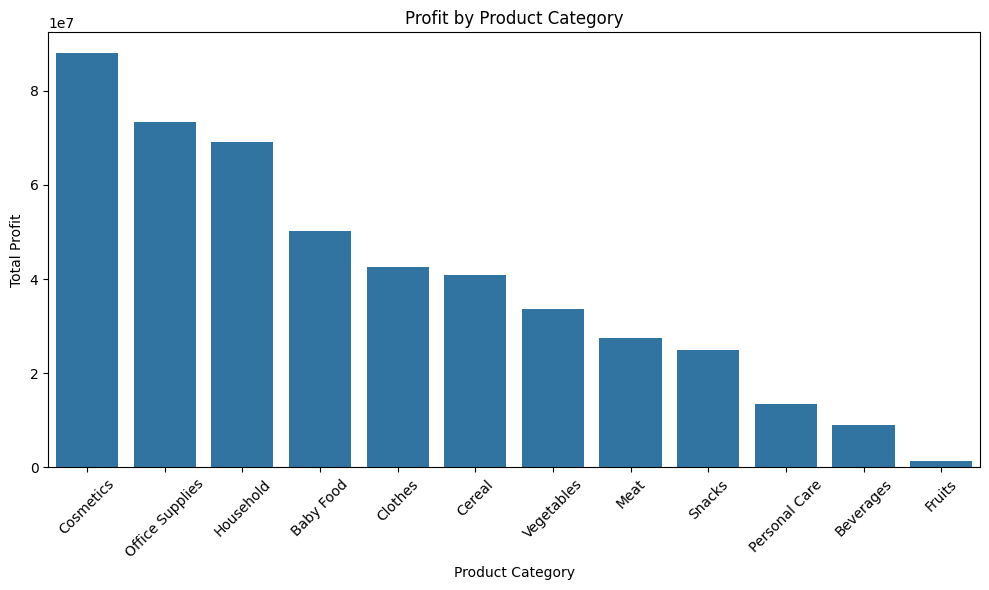

In [ ]:
# Group by category
category_analysis = (
    df.groupby("product_category", as_index=False)
    .agg(
        total_revenue=("revenue", "sum"),
        total_cost=("cost", "sum"),
        total_profit=("profit", "sum"),
        total_units=("units_sold", "sum")
    )
    .sort_values("total_profit", ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(data=category_analysis, x="product_category", y="total_profit")

plt.title("Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

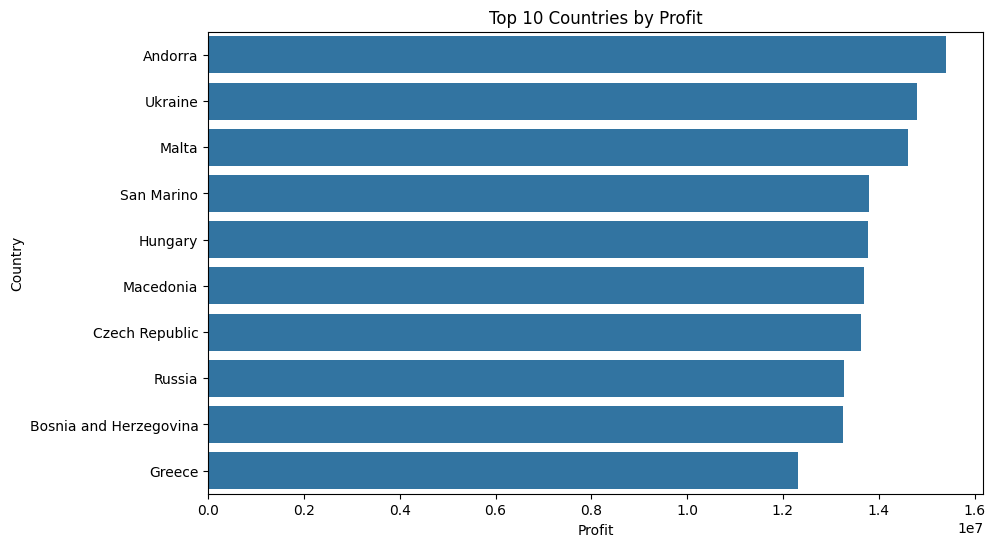

In [ ]:
# Country analysis
country_analysis = (
    df.groupby("country", as_index=False)
    .agg(
        total_revenue=("revenue", "sum"),
        total_profit=("profit", "sum"),
        total_units=("units_sold", "sum")
    )
    .sort_values("total_profit", ascending=False)
)

# Top 10 countries
top_countries = country_analysis.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_countries, x="total_profit", y="country")
plt.title("Top 10 Countries by Profit")
plt.xlabel("Profit")
plt.ylabel("Country")
plt.show()

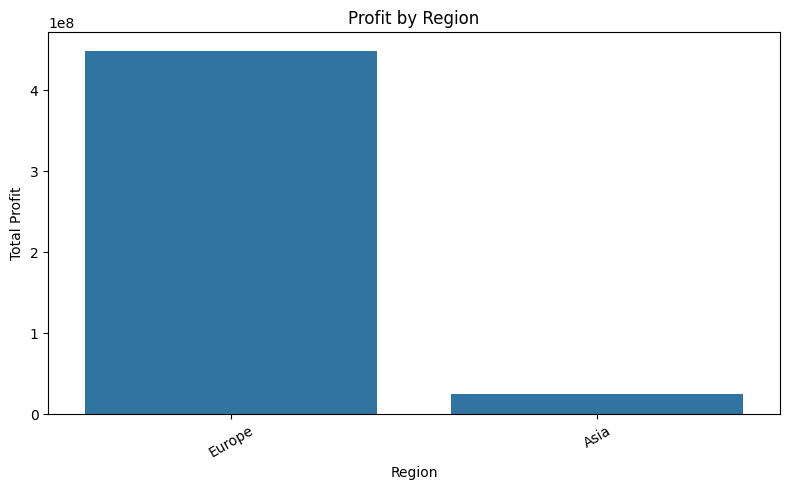

In [ ]:
# Region analysis
region_analysis = (
    df.groupby("region", as_index=False)
    .agg(
        total_revenue=("revenue", "sum"),
        total_cost=("cost", "sum"),
        total_profit=("profit", "sum"),
        total_units=("units_sold", "sum")
    )
    .sort_values("total_profit", ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(data=region_analysis, x="region", y="total_profit")
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

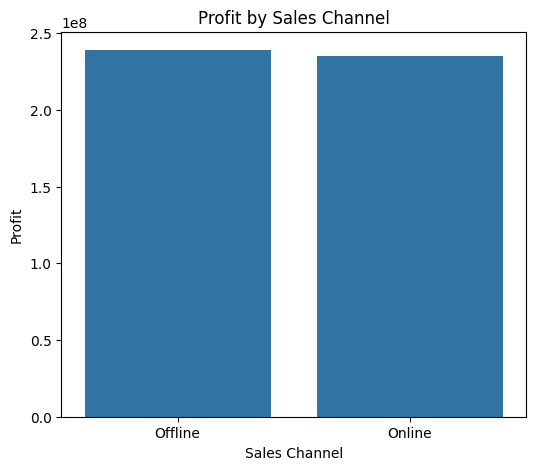

In [ ]:
# Analysis by sales channel
channel_analysis = (
    df.groupby("sales_channel", as_index=False)
    .agg(
        total_revenue=("revenue", "sum"),
        total_profit=("profit", "sum"),
        total_units=("units_sold", "sum")
    )
)

plt.figure(figsize=(6, 5))
sns.barplot(data=channel_analysis, x="sales_channel", y="total_profit")
plt.title("Profit by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Profit")
plt.show()

## Sales Analysis Insights

The analysis shows that sales performance differs across product categories, geography, and sales channels.

Some product categories generate significantly higher profit than others, while product popularity can also be evaluated through total units sold.

Geographically, certain countries and regions contribute more strongly to total profit, which may indicate stronger market demand.

Sales channels were standardized before analysis to avoid duplicated categories such as "Online" and "online". After cleaning, the comparison between Online and Offline channels became accurate.

##We analyze the time between order date and ship date to understand delivery efficiency across:

- product categories
- countries
- regions

In [ ]:
# Convert date columns to datetime
df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"] = pd.to_datetime(df["ship_date"])

# Create delivery time (in days)
df["delivery_days"] = (df["ship_date"] - df["order_date"]).dt.days

df["delivery_days"].describe()

,delivery_days
count,1248.000000
mean,24.863782
std,14.614228
min,0.000000
25%,12.000000
50%,25.000000
75%,37.000000
max,50.000000


##Delivery time analysis shows that:

- The average delivery time is around 25 days, indicating relatively long logistics cycles
- The presence of 0-day deliveries suggests some orders are shipped immediately
- The maximum delivery time of 50 days may indicate delays or long-distance shipments

In [ ]:
# Check for anomalies in delivery time
print("Negative delivery days:", (df["delivery_days"] < 0).sum())
print("Zero delivery days (same-day shipping):", (df["delivery_days"] == 0).sum())

Negative delivery days: 0
Zero delivery days (same-day shipping): 19


### Additional Observations

- No negative delivery times were found, indicating no data inconsistencies
- There are 20 cases of 0-day delivery, which likely represent same-day shipping and are not considered anomalies

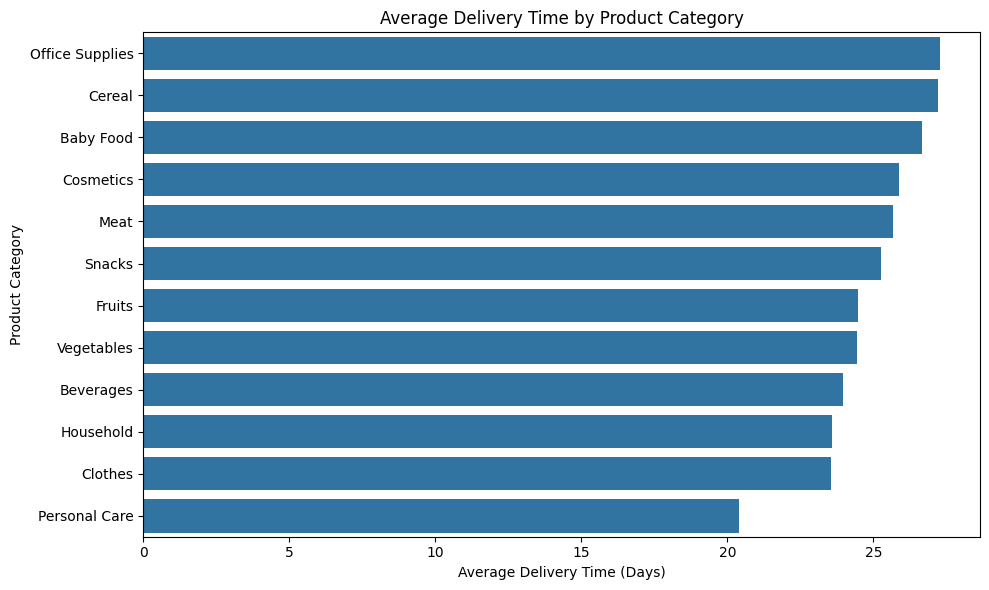

In [ ]:
#Analysis by Product Category
category_delivery = (
    df.groupby("product_category", as_index=False)
    .agg(
        avg_delivery_days=("delivery_days", "mean"),
        median_delivery_days=("delivery_days", "median"),
        max_delivery_days=("delivery_days", "max")
    )
    .sort_values("avg_delivery_days", ascending=False)
)
plt.figure(figsize=(10, 6))

sns.barplot(data=category_delivery, x="avg_delivery_days", y="product_category")
plt.title("Average Delivery Time by Product Category")
plt.xlabel("Average Delivery Time (Days)")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

- The average delivery time is around 25 days, indicating relatively long logistics cycles

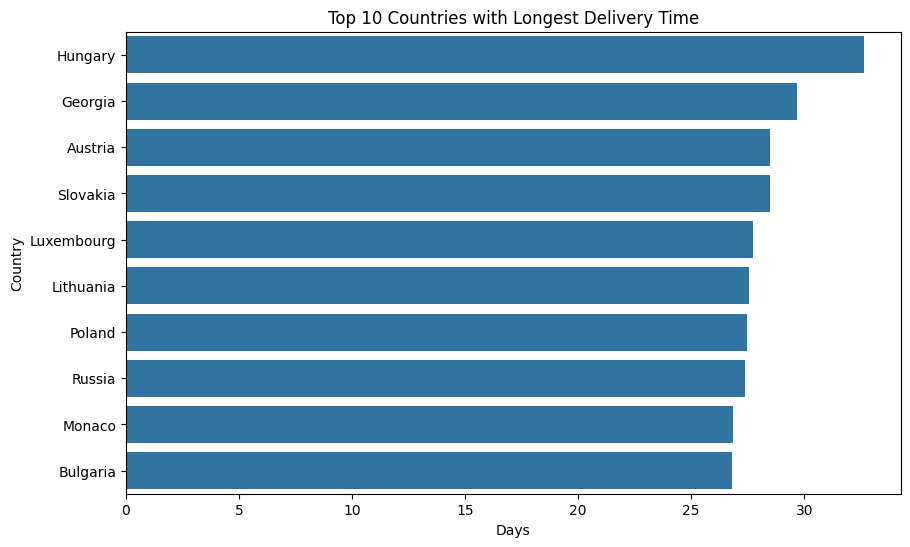

In [ ]:
#Analysis by Country (Top 10)
country_delivery = (
    df.groupby("country", as_index=False)
    .agg(avg_delivery_days=("delivery_days", "mean"))
    .sort_values("avg_delivery_days", ascending=False)
)

top_countries = country_delivery.head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_countries, x="avg_delivery_days", y="country")
plt.title("Top 10 Countries with Longest Delivery Time")
plt.xlabel("Days")
plt.ylabel("Country")
plt.show()

- Some countries experience longer delivery times, possibly due to distance or infrastructure

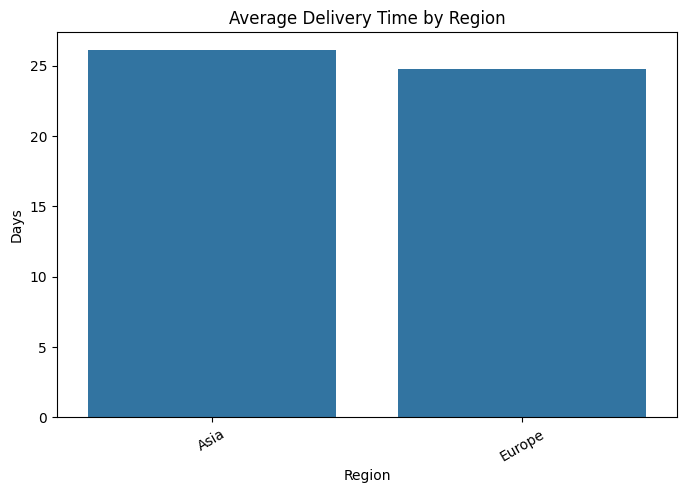

In [ ]:
#Analysis by Region
region_delivery = (
    df.groupby("region", as_index=False)
    .agg(avg_delivery_days=("delivery_days", "mean"))
    .sort_values("avg_delivery_days", ascending=False)
)

plt.figure(figsize=(8,5))
sns.barplot(data=region_delivery, x="region", y="avg_delivery_days")
plt.title("Average Delivery Time by Region")
plt.ylabel("Days")
plt.xlabel("Region")
plt.xticks(rotation=30)
plt.show()

- Asia shows slightly longer delivery times compared to Europe

## Profit vs Delivery Time

We analyze whether delivery time affects profit.

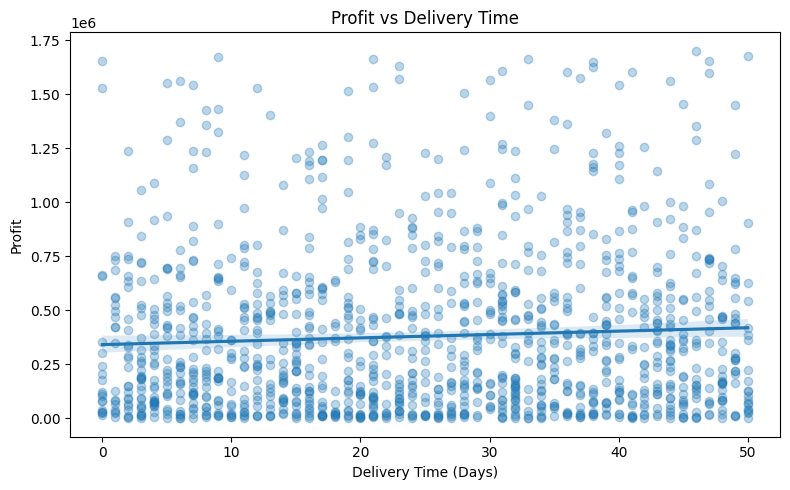

In [ ]:
# Delivery time
df["delivery_days"] = (df["ship_date"] - df["order_date"]).dt.days

# Profit
df["profit"] = (df["unit_price"] - df["unit_cost"]) * df["units_sold"]

# Visualization
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x="delivery_days",
    y="profit",
    scatter_kws={"alpha": 0.3}
)

plt.title("Profit vs Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [ ]:
df[["delivery_days", "profit"]].corr()

,delivery_days,profit
delivery_days,1.000000,0.061084
profit,0.061084,1.000000


## Conclusion

There is no strong dependency between delivery time and profit.

The scatter plot shows a wide distribution of data points, and the trend line is nearly flat.
The correlation coefficient confirms a very weak relationship.

This suggests that delivery speed does not significantly affect profitability.

## Sales Dynamics Analysis

The goal of this analysis is to examine how sales evolve over time and identify key trends across:

- Product categories  
- Regions  
- Countries  

Understanding these patterns helps identify seasonality, growth trends, and key markets driving revenue.

In [ ]:
df["revenue"] = df["unit_price"] * df["units_sold"]
df["order_year"] = pd.to_datetime(df["order_date"]).dt.year
df["order_month"] = pd.to_datetime(df["order_date"]).dt.month

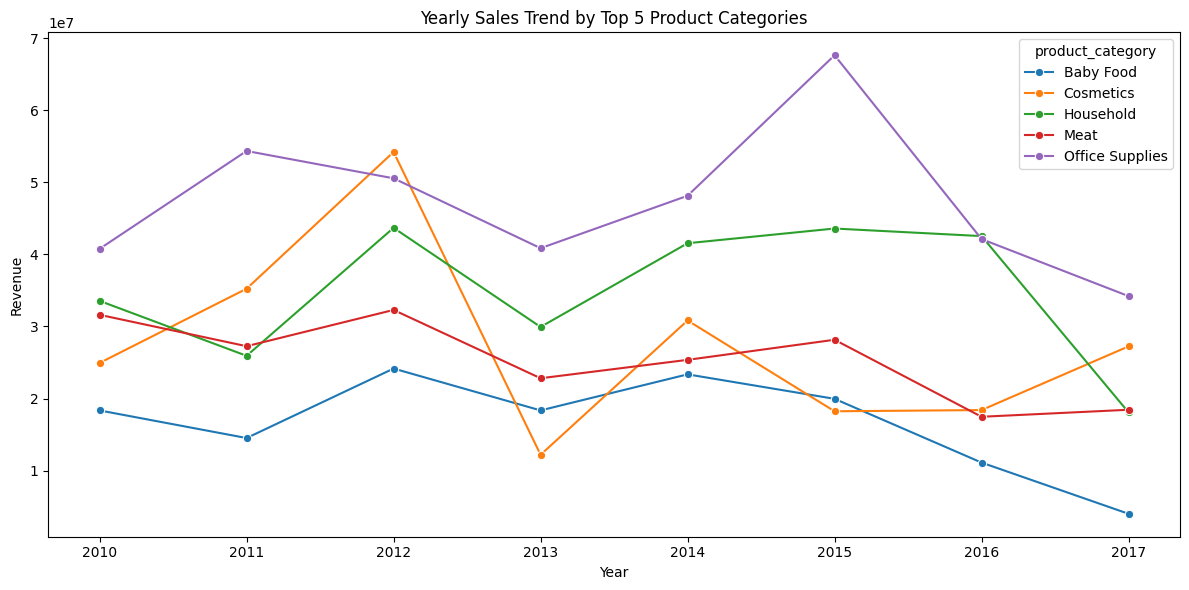

In [ ]:
# Sales dynamics by product category: yearly
# Select top 5 product categories by total revenue
top_categories = (
    df.groupby("product_category")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# Aggregate revenue by year and product category
category_trend_year = (
    df[df["product_category"].isin(top_categories)]
    .groupby(["order_year", "product_category"], as_index=False)
    .agg(total_revenue=("revenue", "sum"))
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=category_trend_year,
    x="order_year",
    y="total_revenue",
    hue="product_category",
    marker="o"
)

plt.title("Yearly Sales Trend by Top 5 Product Categories")
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

- Office Supplies, Household, and Meat consistently generate the highest revenue.
- Some categories (e.g., Cosmetics) show higher volatility, likely due to promotions or irregular demand.
- Lower-performing categories (e.g., Baby Food) show weaker and declining trends.


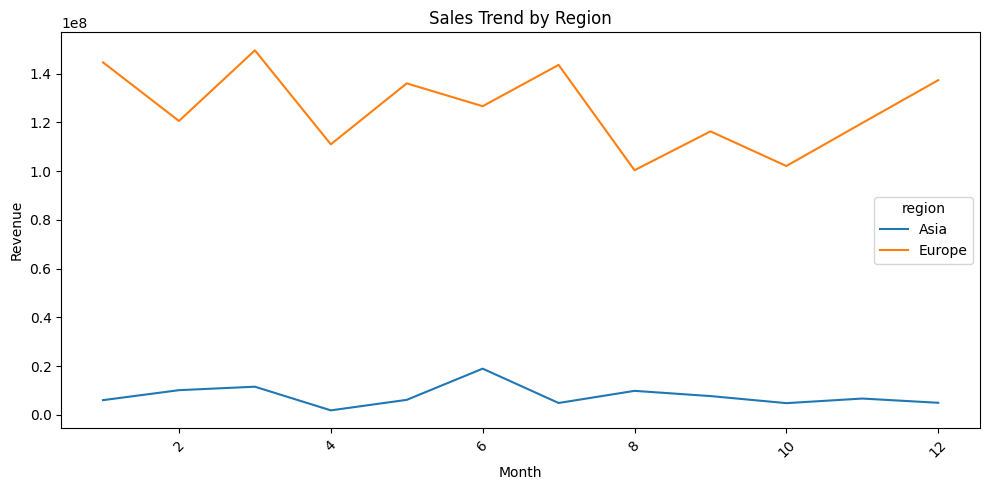

In [ ]:
# Sales dynamics by region
region_trend = (
    df.groupby(["order_month", "region"], as_index=False)
    .agg(total_revenue=("revenue", "sum"))
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=region_trend,
    x="order_month",
    y="total_revenue",
    hue="region"
)

plt.title("Sales Trend by Region")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(8))
plt.tight_layout()
plt.show()

- **Regional analysis shows that Europe consistently outperforms Asia** in total revenue, suggesting stronger market presence or higher demand.

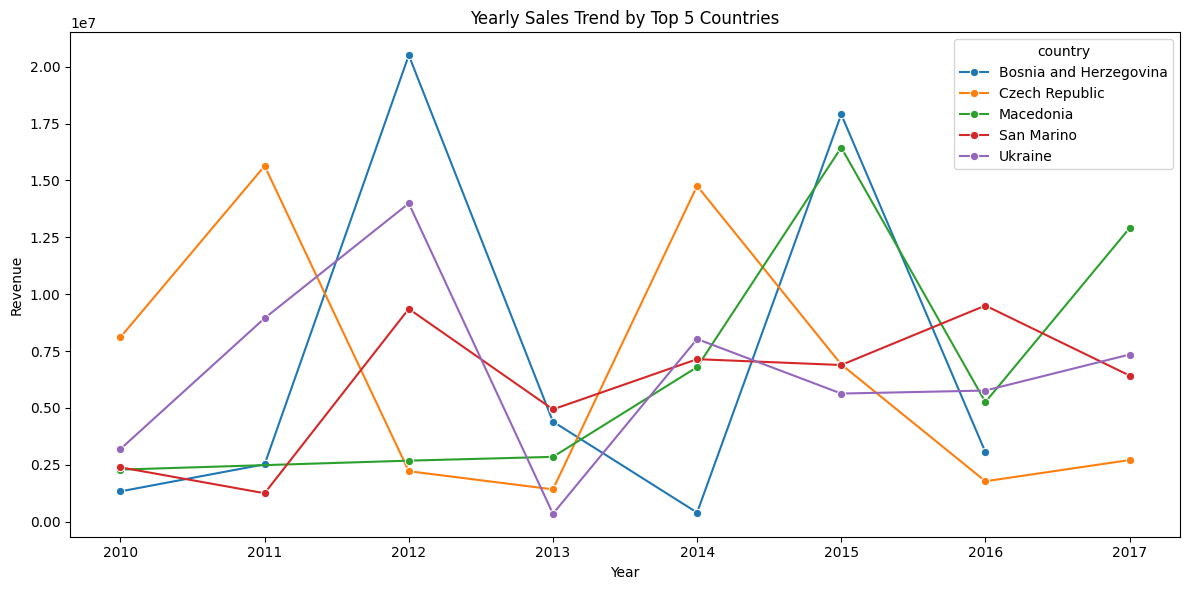

In [ ]:
# Sales dynamics by top 5 countries
top_countries = (
    df.groupby("country")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# Aggregate revenue by year
country_trend = (
    df[df["country"].isin(top_countries)]
    .groupby(["order_year", "country"], as_index=False)
    .agg(total_revenue=("revenue", "sum"))
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=country_trend,
    x="order_year",
    y="total_revenue",
    hue="country",
    marker="o"
)

plt.title("Yearly Sales Trend by Top 5 Countries")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.xticks(country_trend["order_year"].unique())
plt.tight_layout()
plt.show()

- Country-level sales show high volatility, with noticeable year-to-year fluctuations.
- Revenue spikes in certain years suggest dependence on large or irregular transactions rather than consistent demand.
- No clear long-term growth trend is observed across the top countries.


## Sales Analysis by Day of the Week

We analyze how sales vary depending on the day of the week to identify potential seasonality patterns.

In [ ]:
df["day_of_week"] = df["order_date"].dt.day_name()

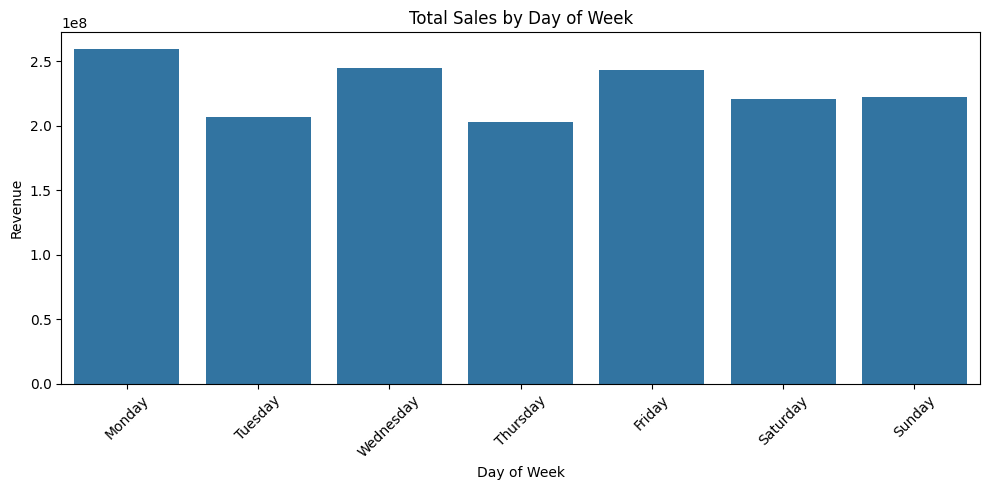

In [ ]:
# Sales by day of week
weekday_sales = (
    df.groupby("day_of_week", as_index=False)
    .agg(total_revenue=("revenue", "sum"))
)

order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_sales["day_of_week"] = pd.Categorical(weekday_sales["day_of_week"], categories=order, ordered=True)
weekday_sales = weekday_sales.sort_values("day_of_week")

plt.figure(figsize=(10, 5))

sns.barplot(
    data=weekday_sales,
    x="day_of_week",
    y="total_revenue"
)

plt.title("Total Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


- Sales are relatively evenly distributed across the week, without extreme peaks or drops, which indicates stable demand.

- Slightly higher revenue is observed on **Monday, Wednesday, and Friday**, suggesting increased business activity at the beginning and end of the workweek.

- Lower sales tend to occur on **Tuesday and Thursday**, which may reflect mid-week slowdowns.

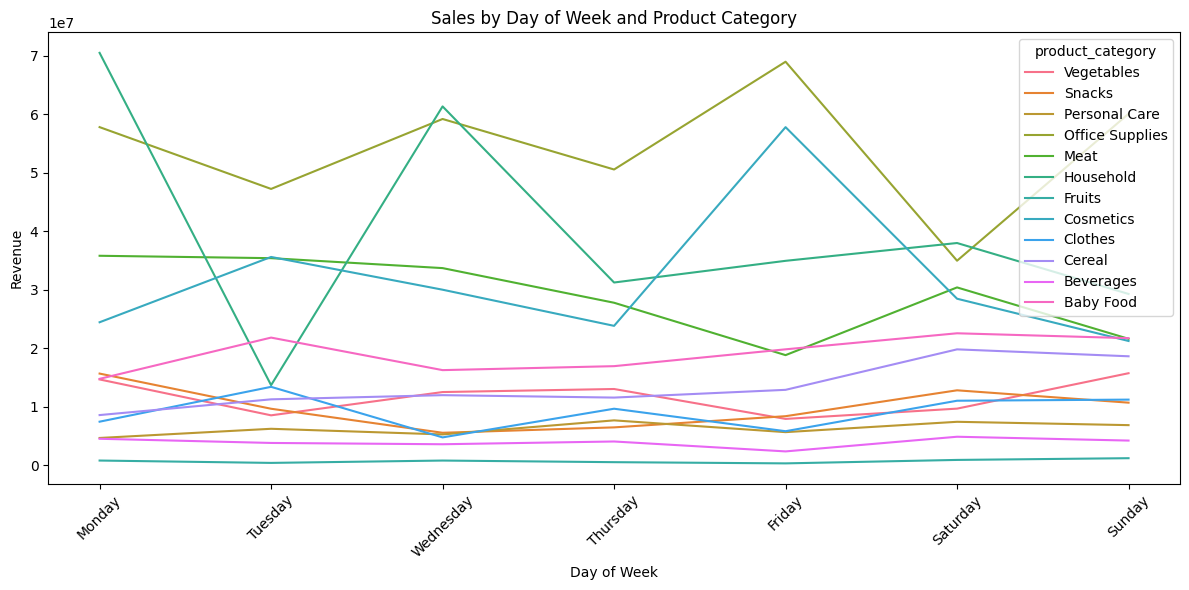

In [ ]:
# Sales by day of week and category
category_weekday = (
    df.groupby(["day_of_week", "product_category"], as_index=False)
    .agg(total_revenue=("revenue", "sum"))
)

category_weekday["day_of_week"] = pd.Categorical(category_weekday["day_of_week"], categories=order, ordered=True)
category_weekday = category_weekday.sort_values("day_of_week")

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=category_weekday,
    x="day_of_week",
    y="total_revenue",
    hue="product_category"
)

plt.title("Sales by Day of Week and Product Category")
plt.xlabel("Day of Week")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

- The category level, some products show mild weekly patterns:
  - Certain categories (e.g., Office Supplies, Household) peak on specific days like Friday or Monday.
  - Others remain stable throughout the week.

Overall, there is **no strong weekly seasonality**, but some categories demonstrate **weak day-of-week preferences**, which could be useful for planning promotions or inventory.

#Summary

The analysis indicates that the business maintains stable demand and consistent revenue streams, with Europe acting as the primary revenue driver. Revenue is concentrated in a limited number of high-performing product categories, while others contribute marginally.

Logistics emerges as a key operational inefficiency, with relatively long delivery times (~25 days). Although this does not currently have a strong impact on profitability, it may pose a risk to scalability and customer satisfaction in the long term.

Sales channels (online vs offline) demonstrate similar performance, suggesting a balanced distribution strategy.

Weekly analysis shows no strong seasonality, but certain product categories exhibit consistent weekday preferences, indicating opportunities for targeted promotions and inventory planning.

**Overall:**
Growth opportunities lie in scaling top-performing categories, strengthening the European market, and improving logistics efficiency to support long-term expansion.